In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import os

data_dir = "/home/surya/AgroScan~/data/AgroScan_Balanced"
class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]
        
        class_counts[class_name] = len(images)

total = 0
for k, v in class_counts.items():
    print(f"{k}: {v}")
    total += v

print("\nTotal images:", total)
print("Total classes:", len(class_counts))

Cotton_Curl_virus: 417
Cotton_Healthy: 426
Potato_Early_blight: 800
Tomato_Healthy: 800
Cotton_Bacterial_blight: 448
Potato_Late_blight: 800
Tomato_Late_blight: 800
Potato_Healthy: 300
Tomato_Early_blight: 800
Pepper_Bacterial_spot: 800
Rice_Diseased: 1493
Cotton_Fusarium_wilt: 419
Pepper_Healthy: 800

Total images: 9103
Total classes: 13


In [5]:
# C:\Users\surya\AgroScan-AttCM-Alex\AgroScan_Final_Dataset
# source_dir = "/mnt/c/Users/surya/AgroScan/data/AgroScan_Balanced"
# target_dir = "/home/surya/AgroScan/data/AgroScan_Split"

In [3]:
import os

base_path = "/home/surya/AgroScan~/data/AgroScan_Split"

grand_total = 0

for split in ["train", "val", "test"]:
    print(f"\n===== {split.upper()} SET =====")

    split_total = 0

    for cls in os.listdir(os.path.join(base_path, split)):
        class_path = os.path.join(base_path, split, cls)

        if not os.path.isdir(class_path):
            continue

        count = len(os.listdir(class_path))
        split_total += count

        print(f"{cls}: {count}")

    print(f"\n➡️ Total {split} images: {split_total}")

    grand_total += split_total

print("\n==============================")
print(f"🔥 TOTAL DATASET IMAGES: {grand_total}")


===== TRAIN SET =====
Cotton_Curl_virus: 291
Cotton_Healthy: 298
Potato_Early_blight: 560
Tomato_Healthy: 560
Cotton_Bacterial_blight: 313
Potato_Late_blight: 560
Tomato_Late_blight: 560
Potato_Healthy: 210
Tomato_Early_blight: 560
Pepper_Bacterial_spot: 560
Rice_Diseased: 1045
Cotton_Fusarium_wilt: 293
Pepper_Healthy: 560

➡️ Total train images: 6370

===== VAL SET =====
Cotton_Curl_virus: 63
Cotton_Healthy: 64
Potato_Early_blight: 120
Tomato_Healthy: 120
Cotton_Bacterial_blight: 67
Potato_Late_blight: 120
Tomato_Late_blight: 120
Potato_Healthy: 45
Tomato_Early_blight: 120
Pepper_Bacterial_spot: 120
Rice_Diseased: 224
Cotton_Fusarium_wilt: 63
Pepper_Healthy: 120

➡️ Total val images: 1366

===== TEST SET =====
Cotton_Curl_virus: 63
Cotton_Healthy: 64
Potato_Early_blight: 120
Tomato_Healthy: 120
Cotton_Bacterial_blight: 68
Potato_Late_blight: 120
Tomato_Late_blight: 120
Potato_Healthy: 45
Tomato_Early_blight: 120
Pepper_Bacterial_spot: 120
Rice_Diseased: 224
Cotton_Fusarium_wilt: 63
P

In [4]:
import os

for split in ["train", "val", "test"]:
    total = sum(len(os.listdir(os.path.join("/home/surya/AgroScan~/data/AgroScan_Split", split, cls)))
                for cls in os.listdir(os.path.join("/home/surya/AgroScan~/data/AgroScan_Split", split)))
    print(split, ":", total)

train : 6370
val : 1366
test : 1367


In [1]:
import os

classes = os.listdir("/home/surya/AgroScan~/data/AgroScan_Balanced")
print(len(classes))
print(classes)

14
['Cotton_Curl_virus', 'Cotton_Healthy', 'Potato_Early_blight', 'Tomato_Healthy', 'Cotton_Bacterial_blight', 'Rice_Healthy', 'Potato_Late_blight', 'Tomato_Late_blight', 'Potato_Healthy', 'Tomato_Early_blight', 'Pepper_Bacterial_spot', 'Rice_Diseased', 'Cotton_Fusarium_wilt', 'Pepper_Healthy']


In [ ]:
import torch    # before removing Rice healthy
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
from collections import Counter

from models.attcm_alex import AttCMAlexNet
from utils.dataset import get_dataloaders
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.5, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

# =========================
# CONFIG
# =========================
DATA_DIR = "data/AgroScan_Split"
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.0003


# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# DATA
# =========================
train_loader, val_loader, test_loader, class_names, num_classes = get_dataloaders(DATA_DIR, BATCH_SIZE)


# =========================
# CLASS WEIGHTS (IMPORTANT)
# =========================
targets = train_loader.dataset.targets
class_counts = Counter(targets)

total_samples = len(targets)
num_classes = len(class_counts)

# weights = [total_samples / class_counts[i] for i in range(num_classes)]
# weights = torch.tensor(weights, dtype=torch.float).to(device)


# =========================
# MODEL
# =========================
model = AttCMAlexNet(num_classes=num_classes).to(device)


# =========================
# LOSS + OPTIMIZER
# =========================
criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)


# =========================
# TRAINING LOOP
# =========================
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    scheduler.step()

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f}")


# =========================
# VALIDATION
# =========================
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nVALIDATION REPORT:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# =========================
# TEST EVALUATION
# =========================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nTEST SET REPORT:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# =========================
# SAVE MODEL
# =========================
torch.save(model.state_dict(), "checkpoints/attcm_alex.pth")
print("\nModel saved successfully!")

Using device: cuda
Epoch [1/30] Loss: 2.1938
Epoch [2/30] Loss: 1.4515
Epoch [3/30] Loss: 1.2638
Epoch [4/30] Loss: 1.1107
Epoch [5/30] Loss: 0.9870
Epoch [6/30] Loss: 0.7857
Epoch [7/30] Loss: 0.6949
Epoch [8/30] Loss: 0.6700
Epoch [9/30] Loss: 0.6193
Epoch [10/30] Loss: 0.5835
Epoch [11/30] Loss: 0.5317
Epoch [12/30] Loss: 0.4920
Epoch [13/30] Loss: 0.5054
Epoch [14/30] Loss: 0.4878
Epoch [15/30] Loss: 0.4818
Epoch [16/30] Loss: 0.4281
Epoch [17/30] Loss: 0.4645
Epoch [18/30] Loss: 0.4353
Epoch [19/30] Loss: 0.4322
Epoch [20/30] Loss: 0.4346
Epoch [21/30] Loss: 0.4342
Epoch [22/30] Loss: 0.4281
Epoch [23/30] Loss: 0.4166
Epoch [24/30] Loss: 0.4162
Epoch [25/30] Loss: 0.4121
Epoch [26/30] Loss: 0.4196
Epoch [27/30] Loss: 0.4128
Epoch [28/30] Loss: 0.4148
Epoch [29/30] Loss: 0.4164
Epoch [30/30] Loss: 0.4194

VALIDATION REPORT:

                         precision    recall  f1-score   support

Cotton_Bacterial_blight       0.69      0.79      0.74        67
      Cotton_Curl_virus     

/home/surya/miniconda3/envs/agroscan/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/surya/miniconda3/envs/agroscan/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/surya/miniconda3/envs/agroscan/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me


TEST SET REPORT:

                         precision    recall  f1-score   support

Cotton_Bacterial_blight       0.71      0.71      0.71        68
      Cotton_Curl_virus       0.63      0.67      0.65        63
   Cotton_Fusarium_wilt       0.83      0.94      0.88        63
         Cotton_Healthy       0.93      0.78      0.85        64
  Pepper_Bacterial_spot       0.84      0.94      0.89       120
         Pepper_Healthy       0.95      0.92      0.93       120
    Potato_Early_blight       0.93      0.97      0.95       120
         Potato_Healthy       0.80      1.00      0.89        45
     Potato_Late_blight       0.79      0.86      0.82       120
          Rice_Diseased       0.65      1.00      0.79       224
           Rice_Healthy       0.00      0.00      0.00       120
    Tomato_Early_blight       0.73      0.75      0.74       120
         Tomato_Healthy       0.94      1.00      0.97       120
     Tomato_Late_blight       0.87      0.52      0.65       120

    

/home/surya/miniconda3/envs/agroscan/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/surya/miniconda3/envs/agroscan/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/surya/miniconda3/envs/agroscan/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [ ]:
import torch    # After removing Rice healthy
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
from collections import Counter

from models.attcm_alex import AttCMAlexNet
from utils.dataset import get_dataloaders
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.5, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

# =========================
# CONFIG
# =========================
DATA_DIR = "data/AgroScan_Split"
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.0003


# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# DATA
# =========================
train_loader, val_loader, test_loader, class_names, num_classes = get_dataloaders(DATA_DIR, BATCH_SIZE)


# =========================
# CLASS WEIGHTS (IMPORTANT)
# =========================
targets = train_loader.dataset.targets
class_counts = Counter(targets)

total_samples = len(targets)
num_classes = len(class_counts)

# weights = [total_samples / class_counts[i] for i in range(num_classes)]
# weights = torch.tensor(weights, dtype=torch.float).to(device)


# =========================
# MODEL
# =========================
model = AttCMAlexNet(num_classes=num_classes).to(device)


# =========================
# LOSS + OPTIMIZER
# =========================
criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)


# =========================
# TRAINING LOOP
# =========================
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    scheduler.step()

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f}")


# =========================
# VALIDATION
# =========================
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nVALIDATION REPORT:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# =========================
# TEST EVALUATION
# =========================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nTEST SET REPORT:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# =========================
# SAVE MODELx
# =========================
torch.save(model.state_dict(), "checkpoints/attcm_alex.pth")
print("\nModel saved successfully!")

Using device: cuda
Epoch [1/30] Loss: 2.2292
Epoch [2/30] Loss: 1.4862
Epoch [3/30] Loss: 1.2164
Epoch [4/30] Loss: 1.0381
Epoch [5/30] Loss: 1.0513
Epoch [6/30] Loss: 0.7693
Epoch [7/30] Loss: 0.6871
Epoch [8/30] Loss: 0.6227
Epoch [9/30] Loss: 0.5951
Epoch [10/30] Loss: 0.5666
Epoch [11/30] Loss: 0.4933
Epoch [12/30] Loss: 0.4770
Epoch [13/30] Loss: 0.4823
Epoch [14/30] Loss: 0.4442
Epoch [15/30] Loss: 0.4348
Epoch [16/30] Loss: 0.4112
Epoch [17/30] Loss: 0.4170
Epoch [18/30] Loss: 0.4256
Epoch [19/30] Loss: 0.3961
Epoch [20/30] Loss: 0.3970
Epoch [21/30] Loss: 0.3989
Epoch [22/30] Loss: 0.4072
Epoch [23/30] Loss: 0.3956
Epoch [24/30] Loss: 0.3827
Epoch [25/30] Loss: 0.3810
Epoch [26/30] Loss: 0.3941
Epoch [27/30] Loss: 0.3855
Epoch [28/30] Loss: 0.3964
Epoch [29/30] Loss: 0.3812
Epoch [30/30] Loss: 0.3901

VALIDATION REPORT:

                         precision    recall  f1-score   support

Cotton_Bacterial_blight       0.76      0.82      0.79        67
      Cotton_Curl_virus     

In [1]:
losses = [
2.2292, 1.4862, 1.2164, 1.0381, 1.0513,
0.7693, 0.6871, 0.6227, 0.5951, 0.5666,
0.4933, 0.4770, 0.4823, 0.4442, 0.4348,
0.4112, 0.4170, 0.4256, 0.3961, 0.3970,
0.3989, 0.4072, 0.3956, 0.3827, 0.3810,
0.3941, 0.3855, 0.3964, 0.3812, 0.3901
]

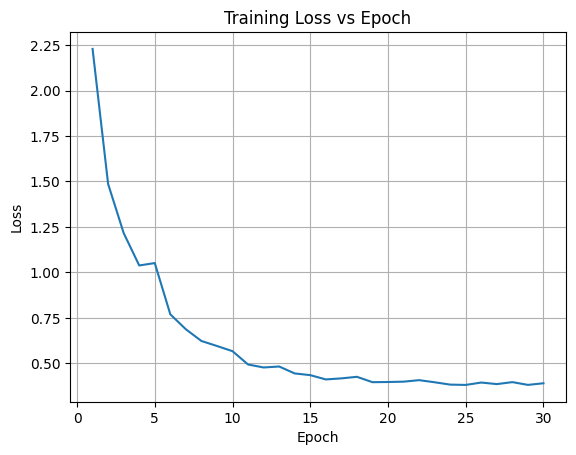

In [4]:
import matplotlib.pyplot as plt

epochs = range(1, len(losses)+1)

plt.figure()
plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid()
plt.show()

In [3]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 3.7 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.
